# Go/NoGo MRCP Classification — new sessions

Works with any recording from `gng_task.py` (with or without self-paced block).
Only the **Config** cell needs editing between sessions.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mne.filter import filter_data
from scipy.signal import welch
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

## Config

**Edit these three lines between sessions.**

In [2]:
SUBJECT = "Z"          # matches --prefix passed to gng_task.py
DATE    = "20260618"   # YYYYMMDD of the recording

PREFIX = SUBJECT
ROOT   = f"../data/subject{SUBJECT}"

# ── fixed params (don't change) ───────────────────────────────────────────────
FS            = 250.0
EPOCH_S       = 1.5
N_EPOCH       = int(EPOCH_S * FS)
LATE_MS       = 200;   N_LATE       = int(LATE_MS / 1000 * FS)
LATE_SLOPE_MS = 500;   N_LATE_SLOPE = int(LATE_SLOPE_MS / 1000 * FS)
N_SEGS        = 6

ALL_COLS      = [f"ch{i}" for i in range(16)]
CENTRAL_IDX   = [1, 3, 5, 9, 11, 13]       # F3 C3 P3 F4 C4 P4
CENTRAL_NAMES = ["F3", "C3", "P3", "F4", "C4", "P4"]
N_CH          = len(CENTRAL_IDX)
SEED          = 42

print(f"SUBJECT={SUBJECT}  DATE={DATE}  ROOT={ROOT}")

SUBJECT=Z  DATE=20260618  ROOT=../data/subjectZ


## Load sessions

In [3]:
stamps = sorted(
    f.split("_")[-1][:-4]
    for f in os.listdir(ROOT)
    if f.startswith(f"{PREFIX}_eeg_{DATE}_") and f.endswith(".csv")
)
assert stamps, f"No files matching {PREFIX}_eeg_{DATE}_*.csv in {ROOT}"
print(f"Found {len(stamps)} session(s): {stamps}")

sessions = {}
for stamp in stamps:
    eeg_df = pd.read_csv(f"{ROOT}/{PREFIX}_eeg_{DATE}_{stamp}.csv")
    mrk_df = pd.read_csv(f"{ROOT}/{PREFIX}_markers_{DATE}_{stamp}.csv")

    raw_ts  = eeg_df["lsl_timestamp"].values
    raw_eeg = eeg_df[ALL_COLS].values.astype(np.float64)
    # ── Timestamp alignment ───────────────────────────────────────────────
    # EEG clock is Unix-epoch; marker clock is boot-relative. The two
    # clocks differ by ~2-3 s beyond a naive stream-start difference.
    # Ground truth: debounce EEG button edges, then pair 1:1 with
    # marker button_press events to get a sub-10 ms accurate offset.
    btn_ch    = eeg_df.iloc[:, -1].values.astype(bool)
    raw_edges = raw_ts[np.where(np.diff(btn_ch.astype(int)) > 0)[0] + 1]
    # debounce: keep only edges > 500 ms after the previous kept edge
    kept = []
    for t in raw_edges:
        if not kept or t - kept[-1] > 0.5:
            kept.append(t)
    deb_edges = np.array(kept)
    press_mrk_ts = mrk_df.loc[
        mrk_df["marker_label"] == "button_press", "lsl_timestamp"
    ].values
    n_pair    = min(len(deb_edges), len(press_mrk_ts))
    ts_offset = float(np.median(deb_edges[:n_pair] - press_mrk_ts[:n_pair]))
    mrk_df["lsl_timestamp"] += ts_offset

    filt = filter_data(raw_eeg.T, FS, 0.5, 4.0, verbose=False).T
    filt -= filt.mean(axis=1, keepdims=True)              # CAR
    eeg_c = filt[:, CENTRAL_IDX].astype(np.float32)

    sessions[stamp] = (raw_ts, eeg_c, mrk_df)
    n_go   = (mrk_df.marker_code == 10).sum()
    n_nogo = (mrk_df.marker_code == 20).sum()
    print(f"  {stamp}: TS_OFFSET={ts_offset:.1f} s  "
          f"{len(eeg_c):,} samples  {len(mrk_df)} markers  "
          f"GO={n_go}  NOGO={n_nogo}")

Found 6 session(s): ['125821', '131405', '133154', '140110', '153514', '155418']
  125821: TS_OFFSET=1781276233.3 s  194,834 samples  503 markers  GO=100  NOGO=100
  131405: TS_OFFSET=1781276233.3 s  193,373 samples  502 markers  GO=100  NOGO=100
  133154: TS_OFFSET=1781276233.3 s  192,279 samples  502 markers  GO=100  NOGO=100
  140110: TS_OFFSET=1781276233.3 s  188,991 samples  504 markers  GO=100  NOGO=100
  153514: TS_OFFSET=1780742191.8 s  190,853 samples  504 markers  GO=100  NOGO=100
  155418: TS_OFFSET=1780742191.8 s  191,897 samples  501 markers  GO=100  NOGO=100


## Epoch extraction

Positive class: actual button presses — **GO hits** (code 30, trial_type=go) **+ self-paced presses** (code 41).  
Negative class: **virtual presses** on NOGO trials at median GO reaction time.  
All epochs are 1.5 s before the press event (t = 0).

In [4]:
def extract_epochs_session(stamp):
    ts, data, mrk = sessions[stamp]

    go_ts    = mrk.loc[mrk.marker_label == "go_onset",     "lsl_timestamp"].values
    hit_ts   = mrk.loc[mrk.marker_label == "hit",          "lsl_timestamp"].values
    press_ts = mrk.loc[
        (mrk.marker_label == "button_press") & (mrk.trial_type == "go"),
        "lsl_timestamp"
    ].values
    sp_ts    = mrk.loc[mrk.marker_code == 41, "lsl_timestamp"].values
    nogo_ts  = mrk.loc[mrk.marker_label == "nogo_onset",   "lsl_timestamp"].values

    rts = [h - go_ts[go_ts < h][-1] for h in hit_ts if len(go_ts[go_ts < h])]
    median_rt = float(np.median(rts)) if rts else 0.8
    virtual_press_ts = nogo_ts + median_rt

    # positive: GO presses + self-paced presses
    pos_ts = np.concatenate([press_ts, sp_ts])

    epochs, labels, kinds = [], [], []
    for ts_arr, label, kind in [
        (pos_ts,            1, "go+sp"),
        (virtual_press_ts,  0, "virtual_nogo"),
    ]:
        for t0 in ts_arr:
            idx   = np.searchsorted(ts, t0)
            start = idx - N_EPOCH
            if start >= 0 and idx <= len(data):
                epochs.append(data[start:idx])
                labels.append(label)
                kinds.append(kind)

    # also return SP epochs separately for the grand average plot
    sp_epochs = []
    for t0 in sp_ts:
        idx   = np.searchsorted(ts, t0)
        start = idx - N_EPOCH
        if start >= 0 and idx <= len(data):
            sp_epochs.append(data[start:idx])

    return (
        np.array(epochs,    dtype=np.float32),
        np.array(labels,    dtype=np.int8),
        np.array(kinds),
        np.array(sp_epochs, dtype=np.float32) if sp_epochs else np.empty((0, N_EPOCH, N_CH), dtype=np.float32),
        median_rt,
    )


all_raw, all_y, all_kinds, all_sp, all_sid = [], [], [], [], []
for sid, stamp in enumerate(stamps):
    raw, y, kinds, sp_ep, med_rt = extract_epochs_session(stamp)
    n_go = (kinds == "go+sp").sum() - len(
        sessions[stamp][2].loc[sessions[stamp][2].marker_code == 41]
    )
    print(f"  Session {sid} ({stamp}): {(y==1).sum()} pos  {(y==0).sum()} neg  "
          f"{len(sp_ep)} SP  median_RT={med_rt*1000:.0f} ms")
    all_raw.append(raw)
    all_y.append(y)
    all_kinds.append(kinds)
    all_sp.append(sp_ep)
    all_sid.append(np.full(len(y), sid, dtype=np.int32))

raw_all   = np.concatenate(all_raw)
y_all     = np.concatenate(all_y)
kinds_all = np.concatenate(all_kinds)
sp_all    = np.concatenate(all_sp) if any(len(s) > 0 for s in all_sp) else None
s_all     = np.concatenate(all_sid)
print(f"\nTotal: {len(y_all)} epochs  {y_all.sum()} pos  shape {raw_all.shape}")
if sp_all is not None:
    print(f"SP epochs for grand avg: {len(sp_all)}")

  Session 0 (125821): 99 pos  100 neg  0 SP  median_RT=357 ms
  Session 1 (131405): 100 pos  100 neg  0 SP  median_RT=366 ms
  Session 2 (133154): 100 pos  100 neg  0 SP  median_RT=360 ms
  Session 3 (140110): 100 pos  100 neg  0 SP  median_RT=345 ms
  Session 4 (153514): 100 pos  100 neg  0 SP  median_RT=355 ms
  Session 5 (155418): 100 pos  100 neg  0 SP  median_RT=379 ms

Total: 1199 epochs  599 pos  shape (1199, 375, 6)


## Grand-average MRCP

Check for a negative ramp at C3/C4 before t=0.  
Blue = GO hits, green = self-paced, red = virtual NOGO.

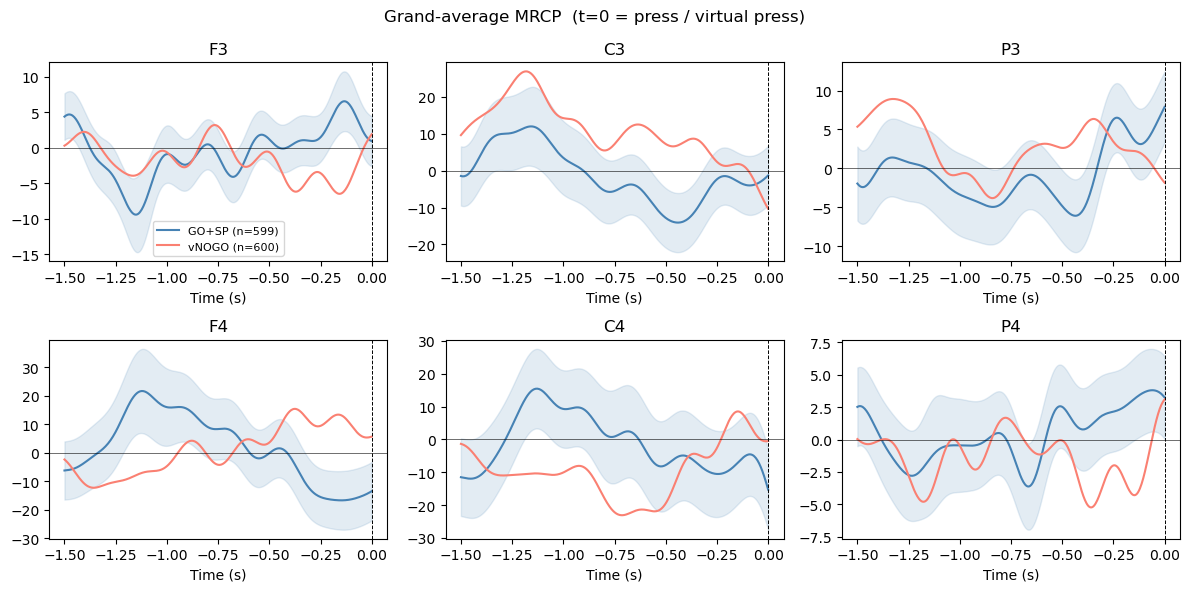

In [5]:
%matplotlib inline

t_ax = np.linspace(-EPOCH_S, 0, N_EPOCH)

# separate GO-only epochs from merged positive class
go_mask   = kinds_all == "go+sp"
nogo_mask = kinds_all == "virtual_nogo"

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (ch_i, ch_name) in zip(axes.flat, enumerate(CENTRAL_NAMES)):
    go_ep   = raw_all[go_mask][:, :, ch_i]
    nogo_ep = raw_all[nogo_mask][:, :, ch_i]

    ax.plot(t_ax, go_ep.mean(0),   color="steelblue", label=f"GO+SP (n={len(go_ep)})")
    ax.plot(t_ax, nogo_ep.mean(0), color="salmon",    label=f"vNOGO (n={len(nogo_ep)})")
    ax.fill_between(t_ax,
        go_ep.mean(0) - go_ep.std(0) / np.sqrt(len(go_ep)),
        go_ep.mean(0) + go_ep.std(0) / np.sqrt(len(go_ep)),
        alpha=0.15, color="steelblue")

    if sp_all is not None and len(sp_all) > 0:
        sp_ep = sp_all[:, :, ch_i]
        ax.plot(t_ax, sp_ep.mean(0), color="seagreen", linestyle="--",
                label=f"SP only (n={len(sp_ep)})")

    ax.axvline(0, color="k", linewidth=0.7, linestyle="--")
    ax.axhline(0, color="k", linewidth=0.4)
    ax.set_title(ch_name); ax.set_xlabel("Time (s)")
    if ch_i == 0: ax.legend(fontsize=8)

fig.suptitle("Grand-average MRCP  (t=0 = press / virtual press)")
plt.tight_layout(); plt.show()

## Feature extraction

In [6]:
def epoch_features(epoch):
    T = epoch.shape[0]
    baseline = epoch[:int(0.1 * FS)].mean(axis=0)
    ep = epoch - baseline
    t_c = np.arange(T, dtype=np.float64) - T / 2

    feat_mean  = ep.mean(axis=0)
    feat_slope = (ep * t_c[:, None]).sum(axis=0) / (t_c ** 2).sum()

    seg_size  = T // N_SEGS
    feat_segs = np.stack(
        [ep[i*seg_size:(i+1)*seg_size].mean(axis=0) for i in range(N_SEGS)]
    ).T.flatten()

    feat_late = ep[-N_LATE:].mean(axis=0)

    ep_ls = ep[-N_LATE_SLOPE:]
    t_ls  = np.arange(N_LATE_SLOPE, dtype=np.float64) - N_LATE_SLOPE / 2
    feat_late_slope = (ep_ls * t_ls[:, None]).sum(axis=0) / (t_ls ** 2).sum()

    _, psd  = welch(ep.T, fs=FS, nperseg=min(T, 128))
    freqs   = np.fft.rfftfreq(min(T, 128), 1.0 / FS)
    feat_delta = psd[:, (freqs >= 0.5) & (freqs <= 4.0)].mean(axis=1)

    return np.concatenate([
        feat_mean, feat_slope, feat_segs, feat_late, feat_late_slope, feat_delta
    ]).astype(np.float32)


X_all = np.array([epoch_features(e) for e in raw_all])
print(f"Feature matrix: {X_all.shape}")

Feature matrix: (1199, 66)


## Leave-one-session-out CV

*(Skipped automatically if only 1 session — shows training metrics instead.)*

In [7]:
_rng = np.random.default_rng(SEED)

def balance(X, y, rng):
    idx0 = np.where(y == 0)[0]; idx1 = np.where(y == 1)[0]
    n    = min(len(idx0), len(idx1))
    idx  = np.concatenate([rng.choice(idx0, n, replace=False),
                           rng.choice(idx1, n, replace=False)])
    return X[np.sort(idx)], y[np.sort(idx)]

def make_clf():
    return make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    )

n_sessions   = len(stamps)
fold_results = []
all_probs    = []
all_true     = []

if n_sessions == 1:
    X_b, y_b = balance(X_all, y_all, _rng)
    clf = make_clf(); clf.fit(X_b, y_b)
    prob = clf.predict_proba(X_all)[:, 1]
    auc  = roc_auc_score(y_all, prob)
    ap   = average_precision_score(y_all, prob)
    fold_results.append(dict(session=0, stamp=stamps[0], auc=auc, ap=ap))
    all_probs.append(prob); all_true.append(y_all)
    print(f"  Single session (train=test):  AUC={auc:.4f}  AP={ap:.4f}  [not a generalisation estimate]")
else:
    for test_sid in range(n_sessions):
        tr = s_all != test_sid; te = s_all == test_sid
        X_tr_b, y_tr_b = balance(X_all[tr], y_all[tr], _rng)
        clf = make_clf(); clf.fit(X_tr_b, y_tr_b)
        prob = clf.predict_proba(X_all[te])[:, 1]
        auc  = roc_auc_score(y_all[te], prob)
        ap   = average_precision_score(y_all[te], prob)
        fold_results.append(dict(session=test_sid, stamp=stamps[test_sid], auc=auc, ap=ap))
        all_probs.append(prob); all_true.append(y_all[te])
        print(f"  Session {test_sid} ({stamps[test_sid]}):  AUC={auc:.4f}  AP={ap:.4f}  "
              f"(train {y_tr_b.sum()} pos + {(y_tr_b==0).sum()} neg)")

    mean_auc = np.mean([r['auc'] for r in fold_results])
    std_auc  = np.std( [r['auc'] for r in fold_results])
    mean_ap  = np.mean([r['ap']  for r in fold_results])
    print(f"\nLOSO  AUC = {mean_auc:.4f} ±{std_auc:.4f}   AP = {mean_ap:.4f}")

all_probs = np.concatenate(all_probs)
all_true  = np.concatenate(all_true)

  Session 0 (125821):  AUC=0.5784  AP=0.5524  (train 500 pos + 500 neg)
  Session 1 (131405):  AUC=0.4248  AP=0.4607  (train 499 pos + 499 neg)
  Session 2 (133154):  AUC=0.4785  AP=0.5084  (train 499 pos + 499 neg)
  Session 3 (140110):  AUC=0.5194  AP=0.5239  (train 499 pos + 499 neg)
  Session 4 (153514):  AUC=0.5048  AP=0.4965  (train 499 pos + 499 neg)
  Session 5 (155418):  AUC=0.5090  AP=0.5418  (train 499 pos + 499 neg)

LOSO  AUC = 0.5025 ±0.0460   AP = 0.5140


## Results

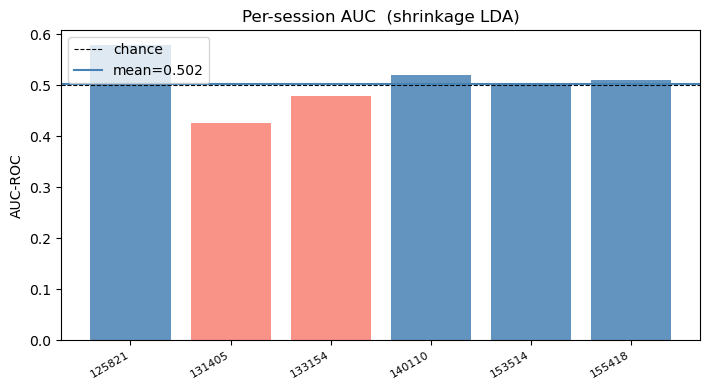

In [8]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(max(6, len(fold_results)*1.2), 4))
sids   = [r["session"] for r in fold_results]
aucs   = [r["auc"]     for r in fold_results]
colors = ["steelblue" if a >= 0.5 else "salmon" for a in aucs]
ax.bar(sids, aucs, color=colors, alpha=0.85)
ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8, label="chance")
if len(fold_results) > 1:
    ax.axhline(mean_auc, color="steelblue", linestyle="-", linewidth=1.5,
               label=f"mean={mean_auc:.3f}")
ax.set_xticks(sids)
ax.set_xticklabels([r["stamp"] for r in fold_results], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("AUC-ROC"); ax.set_title("Per-session AUC  (shrinkage LDA)")
ax.legend(); plt.tight_layout(); plt.show()

## Threshold Calibration

Aggregate ROC from all LOTO/LOSO folds — each epoch scored by the model
that never saw it during training.

Candidate thresholds:
- **Youden's J** — maximises sensitivity + specificity
- **Sens ≥ 0.80 / 0.90** — catch most presses
- **Spec ≥ 0.90 / 0.95** — low false-alarm rate (military priority)


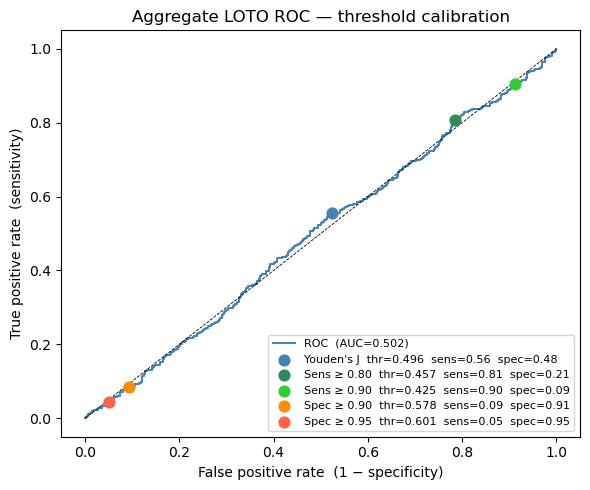

Name            Threshold  Sensitivity  Specificity
----------------------------------------------------
Youden's J          0.496        0.556        0.477
Sens ≥ 0.80         0.457        0.808        0.215
Sens ≥ 0.90         0.425        0.905        0.088
Spec ≥ 0.90         0.578        0.085        0.907
Spec ≥ 0.95         0.601        0.045        0.950


In [9]:
%matplotlib inline
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(all_true, all_probs)
spec = 1 - fpr

# candidate thresholds
j_idx      = np.argmax(tpr + spec - 1)                        # Youden's J
s80_idx    = np.argmax(tpr >= 0.80)                           # sens >= 0.80
s90_idx    = np.argmax(tpr >= 0.90)                           # sens >= 0.90
sp90_idx   = np.where(spec >= 0.90)[0][-1] if (spec >= 0.90).any() else 0
sp95_idx   = np.where(spec >= 0.95)[0][-1] if (spec >= 0.95).any() else 0

candidates = [
    ("Youden's J",   j_idx,    "steelblue"),
    ("Sens ≥ 0.80",  s80_idx,  "seagreen"),
    ("Sens ≥ 0.90",  s90_idx,  "limegreen"),
    ("Spec ≥ 0.90",  sp90_idx, "darkorange"),
    ("Spec ≥ 0.95",  sp95_idx, "tomato"),
]

auc_label = mean_auc if n_sessions > 1 else roc_auc_score(all_true, all_probs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", linewidth=1.5,
        label=f"ROC  (AUC={auc_label:.3f})")
ax.plot([0, 1], [0, 1], color="k", linewidth=0.6, linestyle="--")

for name, idx, color in candidates:
    ax.scatter(fpr[idx], tpr[idx], s=60, color=color, zorder=5,
               label=f"{name}  thr={thresholds[idx]:.3f}  "
                     f"sens={tpr[idx]:.2f}  spec={spec[idx]:.2f}")

ax.set_xlabel("False positive rate  (1 − specificity)")
ax.set_ylabel("True positive rate  (sensitivity)")
ax.set_title("Aggregate LOTO ROC — threshold calibration")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# summary table
print(f"{'Name':<14} {'Threshold':>10} {'Sensitivity':>12} {'Specificity':>12}")
print("-" * 52)
for name, idx, _ in candidates:
    print(f"{name:<14} {thresholds[idx]:>10.3f} "
          f"{tpr[idx]:>12.3f} {spec[idx]:>12.3f}")

## Live prediction — Youden's J threshold

Slides a `STRIDE`-sample window over the continuous EEG, extracts features,
and plots the classifier output over time.  
Blue verticals = GO presses, green = self-paced presses.  
Red fill = classifier fires above Youden's J threshold.

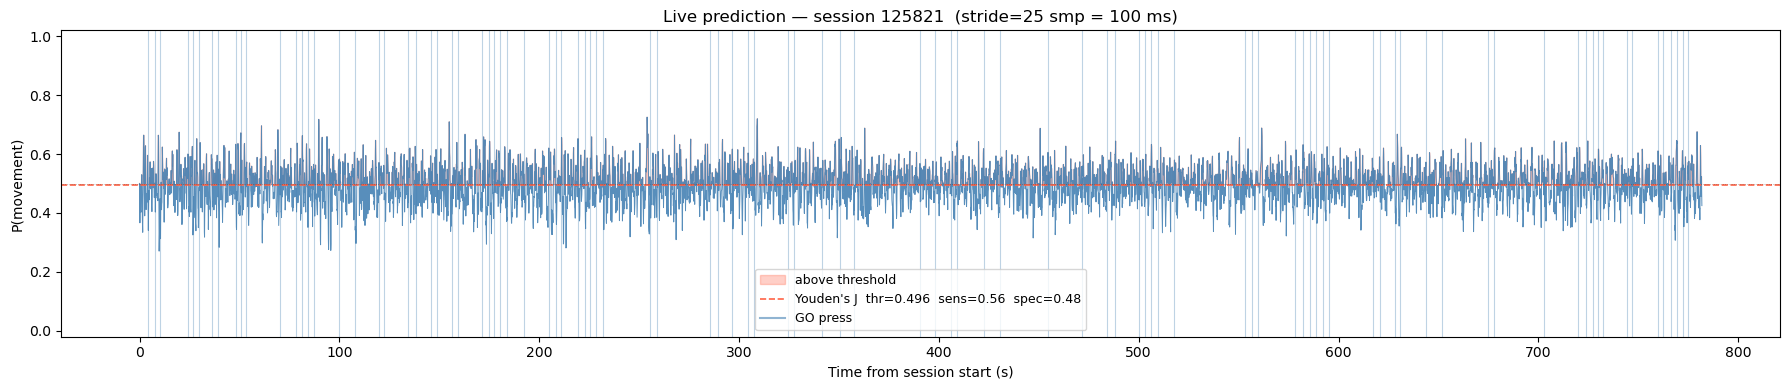

Threshold crossings (rising edges): 972
True GO presses in session: 99   SP presses: 0


In [10]:
%matplotlib inline

# ── Final classifier trained on all data ─────────────────────────────────
# (for LOSO: clf is last fold; retrain here so we always show full-data model)
X_b_viz, y_b_viz = balance(X_all, y_all, _rng)
clf_viz = make_clf()
clf_viz.fit(X_b_viz, y_b_viz)

# ── Session to visualize ─────────────────────────────────────────────────
VIZ_SID = 0        # session index; 0 = first, -1 = last
STRIDE  = 25       # samples between predictions (100 ms @ 250 Hz)

stamp_viz        = stamps[VIZ_SID]
ts_v, data_v, mrk_v = sessions[stamp_viz]
t0 = ts_v[N_EPOCH]

probs_live, t_live = [], []
for i in range(N_EPOCH, len(data_v), STRIDE):
    feat = epoch_features(data_v[i - N_EPOCH:i]).reshape(1, -1)
    probs_live.append(clf_viz.predict_proba(feat)[0, 1])
    t_live.append(ts_v[i] - t0)

probs_live = np.array(probs_live)
t_live     = np.array(t_live)
THR        = thresholds[j_idx]

# ── Marker times relative to session start ───────────────────────────────
go_press_rel = mrk_v.loc[
    (mrk_v.marker_code == 30) & (mrk_v.trial_type == "go"),
    "lsl_timestamp"
].values - t0
sp_press_rel = mrk_v.loc[
    mrk_v.marker_code == 41,
    "lsl_timestamp"
].values - t0

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 4))

ax.plot(t_live, probs_live, color="steelblue", linewidth=0.7, alpha=0.9)
ax.fill_between(t_live, THR, probs_live,
                where=(probs_live >= THR), interpolate=True,
                color="tomato", alpha=0.3, label="above threshold")
ax.axhline(THR, color="tomato", linewidth=1.2, linestyle="--",
           label=f"Youden's J  thr={THR:.3f}  "
                 f"sens={tpr[j_idx]:.2f}  spec={spec[j_idx]:.2f}")
ax.axhline(0.5, color="k", linewidth=0.5, linestyle=":", alpha=0.4)

for t in go_press_rel:
    if 0 <= t <= t_live[-1]:
        ax.axvline(t, color="steelblue", alpha=0.35, linewidth=0.8)
for t in sp_press_rel:
    if 0 <= t <= t_live[-1]:
        ax.axvline(t, color="seagreen", alpha=0.35, linewidth=0.8)

# dummy lines for legend entries
ax.axvline(np.nan, color="steelblue", alpha=0.6, linewidth=1.5, label="GO press")
if len(sp_press_rel) > 0:
    ax.axvline(np.nan, color="seagreen", alpha=0.6, linewidth=1.5, label="SP press")

ax.set_xlabel("Time from session start (s)")
ax.set_ylabel("P(movement)")
ax.set_title(f"Live prediction — session {stamp_viz}  "
             f"(stride={STRIDE} smp = {1000*STRIDE/FS:.0f} ms)")
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Detection summary ────────────────────────────────────────────────────
det_mask = probs_live >= THR
n_detect = int(np.diff(det_mask.astype(int)).clip(0).sum())
n_go     = int((go_press_rel >= 0).sum())
n_sp     = int((sp_press_rel >= 0).sum())
print(f"Threshold crossings (rising edges): {n_detect}")
print(f"True GO presses in session: {n_go}   SP presses: {n_sp}")


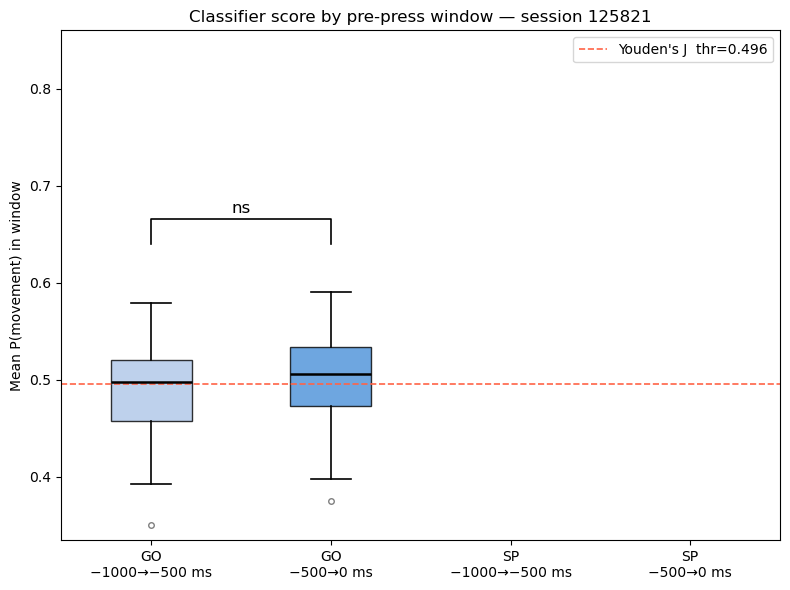

Group                       n    median      mean
------------------------------------------------
GO −1000→−500 ms           99     0.497     0.491
GO −500→0 ms               99     0.506     0.500
SP −1000→−500 ms            0   no data
SP −500→0 ms                0   no data

Pairwise tests
  Wilcoxon (paired)
    GO  early vs late : p=0.1669  ns
  Mann-Whitney U (unpaired)


In [11]:
%matplotlib inline
from scipy.stats import wilcoxon, mannwhitneyu

W1_START, W1_END = -1.000, -0.500  # s
W2_START, W2_END = -0.500,  0.000  # s

def paired_scores(press_times, t_arr, prob_arr):
    """Mean score in each window per press; only includes presses where both windows have data."""
    s1, s2 = [], []
    for tp in press_times:
        m1 = (t_arr >= tp + W1_START) & (t_arr < tp + W1_END)
        m2 = (t_arr >= tp + W2_START) & (t_arr < tp + W2_END)
        if m1.sum() > 0 and m2.sum() > 0:
            s1.append(prob_arr[m1].mean())
            s2.append(prob_arr[m2].mean())
    return np.array(s1), np.array(s2)

GO_W1, GO_W2 = paired_scores(go_press_rel, t_live, probs_live)
SP_W1, SP_W2 = paired_scores(sp_press_rel, t_live, probs_live)

groups = [GO_W1, GO_W2, SP_W1, SP_W2]
labels = ["GO\n−1000→−500 ms", "GO\n−500→0 ms",
          "SP\n−1000→−500 ms", "SP\n−500→0 ms"]
colors = ["#aec6e8", "#4a90d9", "#a8d8b8", "#3aad6a"]

# ── Pairwise tests ────────────────────────────────────────────────────────
def pval_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

# paired Wilcoxon — same trials, early vs late window
_, p_go = wilcoxon(GO_W1, GO_W2)
_, p_sp = wilcoxon(SP_W1, SP_W2) if len(SP_W1) >= 10 else (None, np.nan)

# Mann-Whitney — GO vs SP, same window (unpaired)
_, p_late  = mannwhitneyu(GO_W2, SP_W2, alternative="two-sided") if len(SP_W2) > 0 else (None, np.nan)
_, p_early = mannwhitneyu(GO_W1, SP_W1, alternative="two-sided") if len(SP_W1) > 0 else (None, np.nan)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(groups, patch_artist=True, notch=False,
                medianprops=dict(color="k", linewidth=1.8),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker="o", markersize=4, alpha=0.5))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.axhline(THR, color="tomato", linewidth=1.2, linestyle="--",
           label=f"Youden's J  thr={THR:.3f}")
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Mean P(movement) in window")
ax.set_title(f"Classifier score by pre-press window — session {stamp_viz}")
ax.legend()

# ── Significance brackets ─────────────────────────────────────────────────
def sig_bracket(ax, x1, x2, y, p, h=0.025, color="k"):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, color=color)
    ax.text((x1 + x2) / 2, y + h + 0.003, pval_stars(p),
            ha="center", va="bottom", fontsize=12, color=color)

top = max(a.max() for a in groups if len(a)) + 0.05

# GO early vs late  (boxes 1-2, paired Wilcoxon)
sig_bracket(ax, 1, 2, top, p_go)
# SP early vs late  (boxes 3-4, paired Wilcoxon)
if not np.isnan(p_sp):
    sig_bracket(ax, 3, 4, top, p_sp)
# GO late vs SP late  (boxes 2-4, Mann-Whitney U)
if not np.isnan(p_late):
    sig_bracket(ax, 2, 4, top + 0.08, p_late, color="dimgray")
# GO early vs SP early  (boxes 1-3, Mann-Whitney U)
if not np.isnan(p_early):
    sig_bracket(ax, 1, 3, top + 0.08, p_early, color="dimgray")

ax.set_ylim(top=top + 0.22)
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────
print(f"{'Group':<24} {'n':>4}  {'median':>8}  {'mean':>8}")
print("-" * 48)
for name, arr in zip(labels, groups):
    label = name.replace("\n", " ")
    if len(arr):
        print(f"{label:<24} {len(arr):>4}  {np.median(arr):>8.3f}  {arr.mean():>8.3f}")
    else:
        print(f"{label:<24}    0   no data")

print()
print("Pairwise tests")
print(f"  Wilcoxon (paired)")
print(f"    GO  early vs late : p={p_go:.4f}  {pval_stars(p_go)}")
if not np.isnan(p_sp):
    print(f"    SP  early vs late : p={p_sp:.4f}  {pval_stars(p_sp)}")
print(f"  Mann-Whitney U (unpaired)")
if not np.isnan(p_late):
    print(f"    GO vs SP  (late)  : p={p_late:.4f}  {pval_stars(p_late)}")
if not np.isnan(p_early):
    print(f"    GO vs SP  (early) : p={p_early:.4f}  {pval_stars(p_early)}")

---
## Stimulus-locked classifier: GO vs NOGO

Epoch: −0.2 s → +0.8 s around stimulus onset.  
Positive = GO trial (subject fires), negative = NOGO trial (subject withholds).  
Same features and CV as above — only the epoch window changes.  
Compare AUC with the movement-locked result to see which signal is more exploitable.

In [12]:
STIM_PRE  = 0.2   # s before stimulus onset
STIM_POST = 0.8   # s after  stimulus onset
N_STIM_PRE  = int(STIM_PRE  * FS)
N_STIM_POST = int(STIM_POST * FS)
N_STIM_EPOCH = N_STIM_PRE + N_STIM_POST

def extract_stim_epochs(stamp):
    ts, data, mrk = sessions[stamp]
    go_ts   = mrk.loc[mrk.marker_code == 10, "lsl_timestamp"].values
    nogo_ts = mrk.loc[mrk.marker_code == 20, "lsl_timestamp"].values

    epochs, labels = [], []
    for ts_arr, label in [(go_ts, 1), (nogo_ts, 0)]:
        for t0 in ts_arr:
            idx = np.searchsorted(ts, t0)
            i0  = idx - N_STIM_PRE
            i1  = idx + N_STIM_POST
            if i0 >= 0 and i1 <= len(data):
                epochs.append(data[i0:i1])
                labels.append(label)

    return np.array(epochs, dtype=np.float32), np.array(labels, dtype=np.int8)


stim_raw_list, stim_y_list, stim_sid_list = [], [], []
for sid, stamp in enumerate(stamps):
    raw, y = extract_stim_epochs(stamp)
    print(f"  Session {sid} ({stamp}): {(y==1).sum()} GO  {(y==0).sum()} NOGO")
    stim_raw_list.append(raw)
    stim_y_list.append(y)
    stim_sid_list.append(np.full(len(y), sid, dtype=np.int32))

stim_raw_all = np.concatenate(stim_raw_list)
stim_y_all   = np.concatenate(stim_y_list)
stim_s_all   = np.concatenate(stim_sid_list)
print(f"\nTotal: {len(stim_y_all)} epochs  shape {stim_raw_all.shape}")

X_stim = np.array([epoch_features(e) for e in stim_raw_all])
print(f"Feature matrix: {X_stim.shape}")

  Session 0 (125821): 99 GO  100 NOGO
  Session 1 (131405): 100 GO  100 NOGO
  Session 2 (133154): 100 GO  100 NOGO
  Session 3 (140110): 100 GO  100 NOGO
  Session 4 (153514): 99 GO  100 NOGO
  Session 5 (155418): 100 GO  100 NOGO

Total: 1198 epochs  shape (1198, 250, 6)
Feature matrix: (1198, 66)


In [13]:
_rng_stim      = np.random.default_rng(SEED)
stim_folds     = []
stim_probs_all = []
stim_true_all  = []

if n_sessions == 1:
    X_b, y_b = balance(X_stim, stim_y_all, _rng_stim)
    clf_stim = make_clf(); clf_stim.fit(X_b, y_b)
    prob = clf_stim.predict_proba(X_stim)[:, 1]
    auc  = roc_auc_score(stim_y_all, prob)
    ap   = average_precision_score(stim_y_all, prob)
    stim_folds.append(dict(session=0, stamp=stamps[0], auc=auc, ap=ap))
    stim_probs_all.append(prob); stim_true_all.append(stim_y_all)
    print(f"  Single session (train=test):  AUC={auc:.4f}  AP={ap:.4f}")
else:
    for test_sid in range(n_sessions):
        tr = stim_s_all != test_sid; te = stim_s_all == test_sid
        X_tr_b, y_tr_b = balance(X_stim[tr], stim_y_all[tr], _rng_stim)
        clf_stim = make_clf(); clf_stim.fit(X_tr_b, y_tr_b)
        prob = clf_stim.predict_proba(X_stim[te])[:, 1]
        auc  = roc_auc_score(stim_y_all[te], prob)
        ap   = average_precision_score(stim_y_all[te], prob)
        stim_folds.append(dict(session=test_sid, stamp=stamps[test_sid], auc=auc, ap=ap))
        stim_probs_all.append(prob); stim_true_all.append(stim_y_all[te])
        print(f"  Session {test_sid} ({stamps[test_sid]}):  AUC={auc:.4f}  AP={ap:.4f}  "
              f"(train {y_tr_b.sum()} pos + {(y_tr_b==0).sum()} neg)")

    stim_mean_auc = np.mean([r['auc'] for r in stim_folds])
    stim_std_auc  = np.std( [r['auc'] for r in stim_folds])
    stim_mean_ap  = np.mean([r['ap']  for r in stim_folds])
    print(f"\nStim-locked LOSO  AUC = {stim_mean_auc:.4f} ±{stim_std_auc:.4f}  "
          f" AP = {stim_mean_ap:.4f}")

stim_probs_all = np.concatenate(stim_probs_all)
stim_true_all  = np.concatenate(stim_true_all)
stim_auc_val   = stim_folds[0]['auc'] if n_sessions == 1 else stim_mean_auc
move_auc_val   = fold_results[0]['auc'] if n_sessions == 1 else mean_auc

  Session 0 (125821):  AUC=0.5644  AP=0.5768  (train 499 pos + 499 neg)
  Session 1 (131405):  AUC=0.4458  AP=0.4563  (train 498 pos + 498 neg)
  Session 2 (133154):  AUC=0.4785  AP=0.5134  (train 498 pos + 498 neg)
  Session 3 (140110):  AUC=0.6062  AP=0.5833  (train 498 pos + 498 neg)
  Session 4 (153514):  AUC=0.4841  AP=0.4765  (train 499 pos + 499 neg)
  Session 5 (155418):  AUC=0.5201  AP=0.5452  (train 498 pos + 498 neg)

Stim-locked LOSO  AUC = 0.5165 ±0.0545   AP = 0.5253


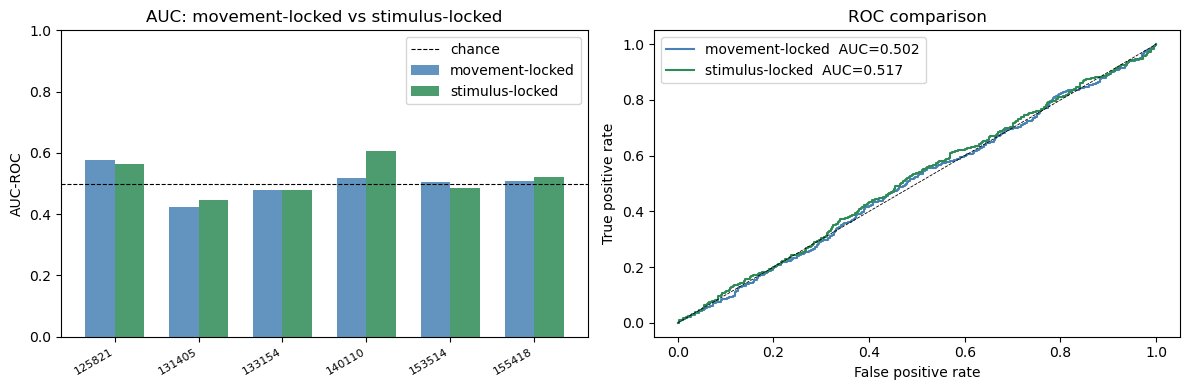

ΔAUC = +0.014  →  stimulus-locked is stronger


In [14]:
%matplotlib inline
from sklearn.metrics import roc_curve as _roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Per-session AUC comparison ────────────────────────────────────────────
ax = axes[0]
x = np.arange(len(stamps))
w = 0.35
move_aucs = [r['auc'] for r in fold_results]
stim_aucs = [r['auc'] for r in stim_folds]
ax.bar(x - w/2, move_aucs, width=w, color="steelblue", alpha=0.85, label="movement-locked")
ax.bar(x + w/2, stim_aucs, width=w, color="seagreen",  alpha=0.85, label="stimulus-locked")
ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8, label="chance")
ax.set_xticks(x)
ax.set_xticklabels(stamps, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("AUC-ROC")
ax.set_ylim(0, 1)
ax.set_title("AUC: movement-locked vs stimulus-locked")
ax.legend()

# ── ROC curves ────────────────────────────────────────────────────────────
ax = axes[1]
fpr_m, tpr_m, _ = _roc_curve(all_true,       all_probs)
fpr_s, tpr_s, _ = _roc_curve(stim_true_all,  stim_probs_all)
ax.plot(fpr_m, tpr_m, color="steelblue", linewidth=1.5,
        label=f"movement-locked  AUC={move_auc_val:.3f}")
ax.plot(fpr_s, tpr_s, color="seagreen",  linewidth=1.5,
        label=f"stimulus-locked  AUC={stim_auc_val:.3f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.6)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC comparison")
ax.legend()

plt.tight_layout()
plt.show()

delta = stim_auc_val - move_auc_val
winner = "stimulus-locked" if delta > 0 else "movement-locked"
print(f"ΔAUC = {delta:+.3f}  →  {winner} is stronger")

## Per-channel AUC

Each channel gets its own shrinkage-LDA trained on that channel's 11 features only.
Channels well below chance (AUC < 0.5) have inverted polarity relative to the model's expectation.
The pooled-channel AUC is shown as reference.

  F3  : AUC=0.503
  C3  : AUC=0.483
  P3  : AUC=0.486
  F4  : AUC=0.506
  C4  : AUC=0.510
  P4  : AUC=0.478


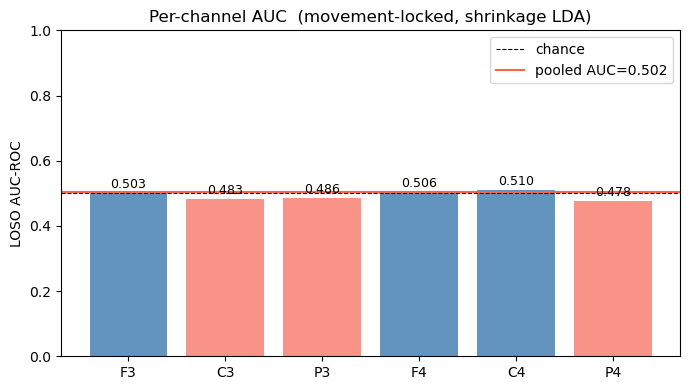

In [15]:
%matplotlib inline

def ch_feat_idx(c):
    """Feature-vector slice for channel c in X_all."""
    base_seg  = 2 * N_CH
    base_late = base_seg + N_CH * N_SEGS
    return ([c, N_CH + c]
            + list(range(base_seg + c * N_SEGS, base_seg + (c + 1) * N_SEGS))
            + [base_late + c, base_late + N_CH + c, base_late + 2 * N_CH + c])

_rng_ch = np.random.default_rng(SEED)
ch_aucs = np.zeros(N_CH)

for c in range(N_CH):
    X_c = X_all[:, ch_feat_idx(c)]
    fold_aucs = []
    if n_sessions == 1:
        X_b, y_b = balance(X_c, y_all, _rng_ch)
        clf_c = make_clf(); clf_c.fit(X_b, y_b)
        fold_aucs.append(roc_auc_score(y_all, clf_c.predict_proba(X_c)[:, 1]))
    else:
        for test_sid in range(n_sessions):
            tr = s_all != test_sid; te = s_all == test_sid
            X_tr_b, y_tr_b = balance(X_c[tr], y_all[tr], _rng_ch)
            clf_c = make_clf(); clf_c.fit(X_tr_b, y_tr_b)
            fold_aucs.append(roc_auc_score(y_all[te], clf_c.predict_proba(X_c[te])[:, 1]))
    ch_aucs[c] = np.mean(fold_aucs)
    print(f'  {CENTRAL_NAMES[c]:4s}: AUC={ch_aucs[c]:.3f}')

pooled_auc = mean_auc if n_sessions > 1 else fold_results[0]['auc']

fig, ax = plt.subplots(figsize=(7, 4))
colors_ch = ['steelblue' if a >= 0.5 else 'salmon' for a in ch_aucs]
bars = ax.bar(CENTRAL_NAMES, ch_aucs, color=colors_ch, alpha=0.85)
ax.axhline(0.5,        color='k',      linestyle='--', linewidth=0.8, label='chance')
ax.axhline(pooled_auc, color='tomato', linestyle='-',  linewidth=1.5,
           label=f'pooled AUC={pooled_auc:.3f}')
for bar, auc in zip(bars, ch_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('LOSO AUC-ROC')
ax.set_ylim(0, 1)
ax.set_title('Per-channel AUC  (movement-locked, shrinkage LDA)')
ax.legend()
plt.tight_layout()
plt.show()


## Single-trial amplitude distributions

Mean amplitude in the MRCP window (last 500 ms before press) per epoch.  
**Cohen's d** quantifies the effect size between GO+SP and virtual-NOGO classes.  
Wide, overlapping violins with small d explain why a clear grand-average ERP does not
translate into good single-trial discrimination.

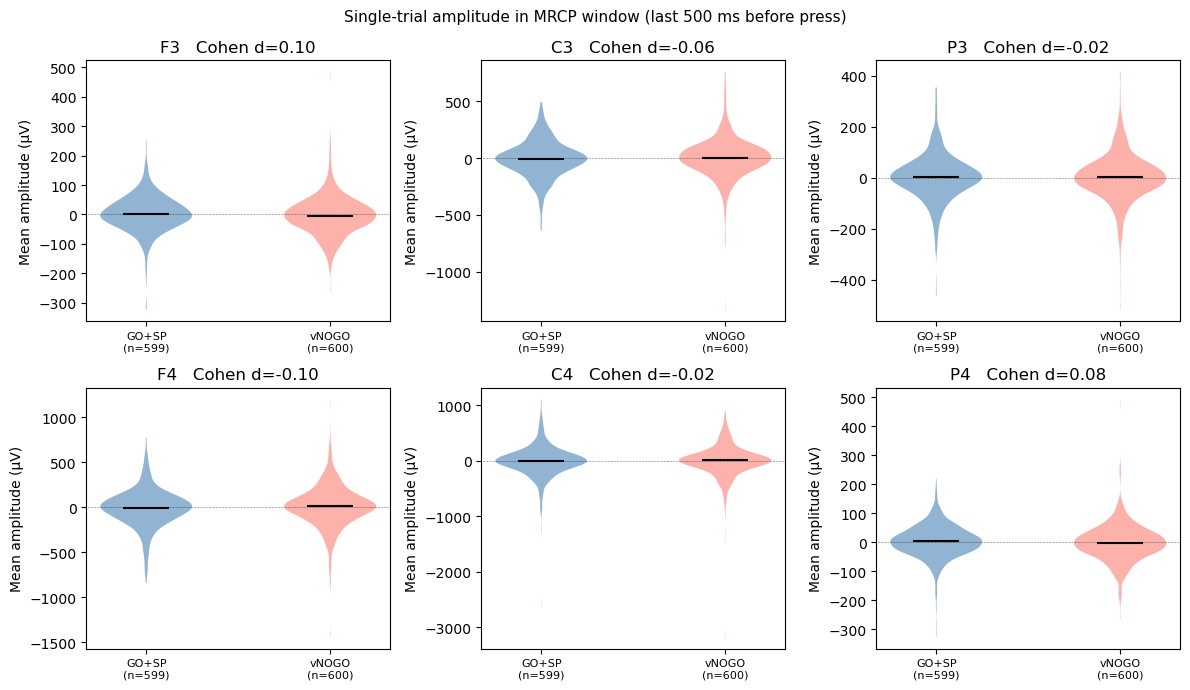

Cohen's d per channel:
  F3  : d=+0.098  GO+SP=2.36±59.77  vNOGO=-3.79±65.20 µV
  C3  : d=-0.056  GO+SP=-6.53±160.24  vNOGO=2.81±174.72 µV
  P3  : d=-0.016  GO+SP=1.55±88.99  vNOGO=3.02±91.72 µV
  F4  : d=-0.097  GO+SP=-10.70±208.84  vNOGO=10.36±227.07 µV
  C4  : d=-0.020  GO+SP=-7.68±275.52  vNOGO=-2.13±283.52 µV
  P4  : d=+0.080  GO+SP=2.35±55.73  vNOGO=-2.40±62.48 µV


In [16]:
%matplotlib inline

late_amp = raw_all[:, -N_LATE_SLOPE:, :].mean(axis=1)  # (n_epochs, N_CH)
pos_mask = y_all == 1
neg_mask = y_all == 0

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, c in zip(axes.flat, range(N_CH)):
    pos_vals = late_amp[pos_mask, c]
    neg_vals = late_amp[neg_mask, c]
    pooled_std = np.sqrt((pos_vals.std()**2 + neg_vals.std()**2) / 2)
    d = (pos_vals.mean() - neg_vals.mean()) / (pooled_std + 1e-9)

    vp = ax.violinplot([pos_vals, neg_vals], positions=[0, 1],
                       showmedians=True, showextrema=False)
    vp['bodies'][0].set_facecolor('steelblue'); vp['bodies'][0].set_alpha(0.6)
    vp['bodies'][1].set_facecolor('salmon');    vp['bodies'][1].set_alpha(0.6)
    vp['cmedians'].set_color('k'); vp['cmedians'].set_linewidth(1.5)
    ax.axhline(0, color='k', linewidth=0.4, linestyle=':')
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'GO+SP\n(n={pos_mask.sum()})',
                        f'vNOGO\n(n={neg_mask.sum()})'], fontsize=8)
    ax.set_title(f'{CENTRAL_NAMES[c]}   Cohen d={d:.2f}')
    ax.set_ylabel('Mean amplitude (µV)')

fig.suptitle('Single-trial amplitude in MRCP window (last 500 ms before press)',
             fontsize=11)
plt.tight_layout()
plt.show()

print('Cohen\'s d per channel:')
for c in range(N_CH):
    pv = late_amp[pos_mask, c]; nv = late_amp[neg_mask, c]
    ps = np.sqrt((pv.std()**2 + nv.std()**2) / 2)
    d  = (pv.mean() - nv.mean()) / (ps + 1e-9)
    print(f'  {CENTRAL_NAMES[c]:4s}: d={d:+.3f}  '
          f'GO+SP={pv.mean():.2f}\u00b1{pv.std():.2f}  '
          f'vNOGO={nv.mean():.2f}\u00b1{nv.std():.2f} \u00b5V')


## ERP image — single-trial variability

Each row is one epoch at the best channel (highest per-channel AUC), sorted by
late-window amplitude.  
If the grand-average MRCP is clear but rows are noisy and mixed, the signal exists
at the population level but is buried in single-trial noise — which is exactly
what limits the classifier.

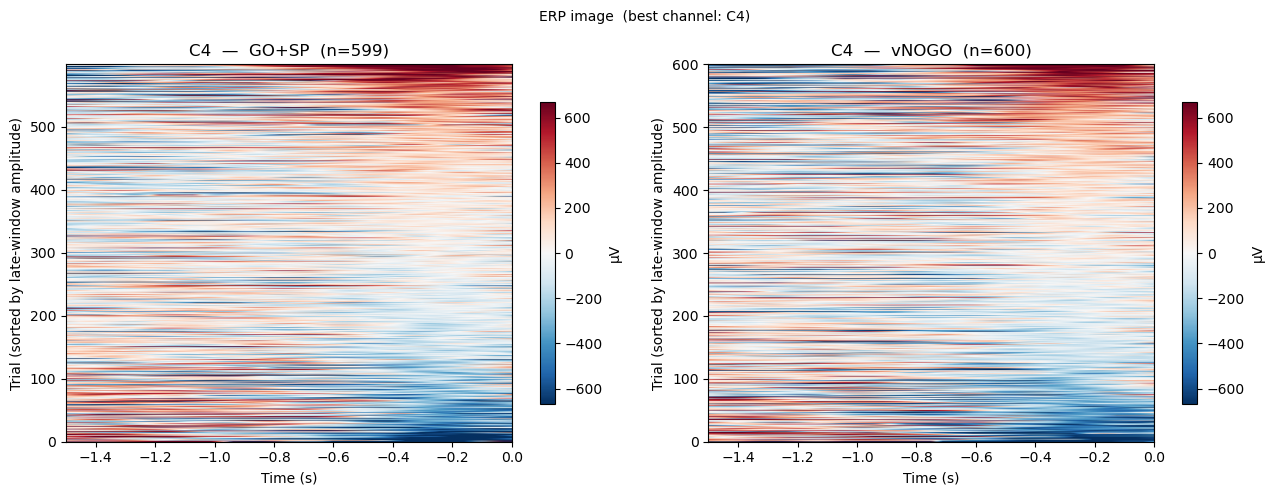

In [17]:
%matplotlib inline

pos_mask   = y_all == 1
neg_mask   = y_all == 0
BEST_CH    = int(np.argmax(ch_aucs))
pos_epochs = raw_all[pos_mask, :, BEST_CH]
neg_epochs = raw_all[neg_mask, :, BEST_CH]
pos_sort   = np.argsort(pos_epochs[:, -N_LATE_SLOPE:].mean(axis=1))
neg_sort   = np.argsort(neg_epochs[:, -N_LATE_SLOPE:].mean(axis=1))

t_ax = np.linspace(-EPOCH_S, 0, N_EPOCH)
vmax = float(np.percentile(np.abs(raw_all[:, :, BEST_CH]), 95))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, epochs, sort_idx, title in [
    (axes[0], pos_epochs, pos_sort, f'GO+SP  (n={len(pos_epochs)})'),
    (axes[1], neg_epochs, neg_sort, f'vNOGO  (n={len(neg_epochs)})'),
]:
    im = ax.imshow(epochs[sort_idx], aspect='auto', origin='lower',
                   extent=[t_ax[0], t_ax[-1], 0, len(epochs)],
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.axvline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Trial (sorted by late-window amplitude)')
    ax.set_title(f'{CENTRAL_NAMES[BEST_CH]}  \u2014  {title}')
    plt.colorbar(im, ax=ax, label='\u00b5V', shrink=0.8)

fig.suptitle(f'ERP image  (best channel: {CENTRAL_NAMES[BEST_CH]})', fontsize=10)
plt.tight_layout()
plt.show()
